In [3]:
import pandas as pd 

fg = pd.read_csv("fear_greed_index.csv")
hist = pd.read_csv("historical_data.csv")

print(fg.shape)
print(fg.head())
print("---")
print(hist.shape)
print(hist.columns.tolist())
print(hist.head())

(2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
---
(211224, 16)
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timesta

In [5]:
import datetime as dt
hist["trade_date"] = pd.to_datetime(hist["Timestamp IST"], format="%d-%m-%Y %H:%M")
hist["trade_date"] =hist["trade_date"].dt.date

In [13]:
fg["date"] = pd.to_datetime(fg["timestamp"],unit="s")
fg["date"] = fg["date"].dt.date

In [14]:
merged = pd.merge(hist, fg, left_on="trade_date", right_on="date", how="left")
print(merged.shape)
print(merged.head())

(211224, 21)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  520

In [15]:
print(merged["value"].isna().sum())

6


In [16]:
merged.groupby("classification")["Closed PnL"].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

Traders achieve highest PnL during extreme greed periods, means traders benefit from riding bullish momentum that is following the market trend rather than going against it 

In [18]:
merged["win"] = (merged["Closed PnL"] >0).astype(int)
merged.groupby("classification")["win"].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

as avl PnL suggested , win rate justifies. Extreme greed gives more profit hence better performance and extreme fear suggests worst performance

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

pnl_by_sentiment = merged.groupby("classification")["Closed PnL"].mean().reset_index()
print(pnl_by_sentiment)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


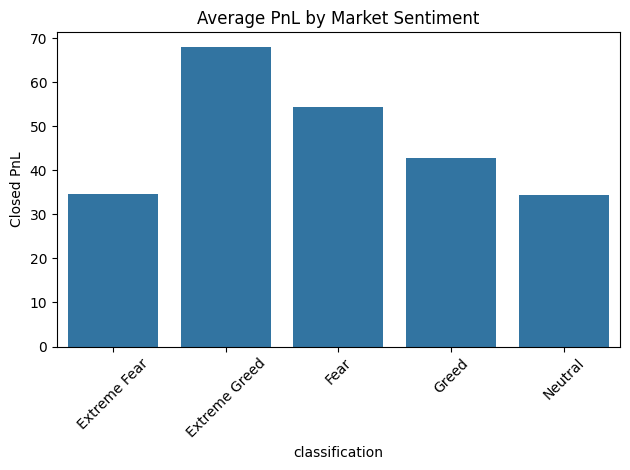

In [20]:
sns.barplot(data=pnl_by_sentiment, x="classification", y="Closed PnL")
plt.title("Average PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

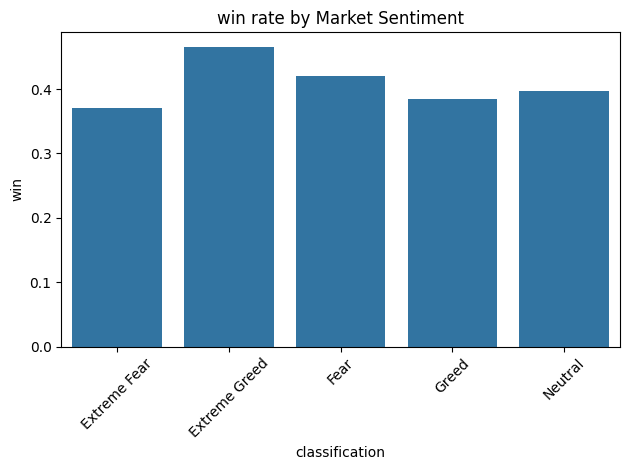

In [21]:
win_by_sentiment = merged.groupby("classification")["win"].mean().reset_index()

sns.barplot(data=win_by_sentiment, x="classification", y="win")
plt.title("win rate by Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
extreme_greed = merged[merged["classification"] == "Extreme Greed"]
extreme_greed.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False).head(10)

Coin
PEOPLE     360.646005
@85        291.819153
CYBER      191.529600
@107       191.158211
MOODENG    165.813219
TURBO      155.581234
XAI        134.276726
MATIC      114.445084
MAVIA      112.597265
ACE        110.428596
Name: Closed PnL, dtype: float64

during extreme greed periods, coins like PEOPLE, @85 and CYBER show the highest average PnL, suggesting these are particularly sensitive to bullish market sentiment and could be a priority in greed driven trading strategy